**Project 3: COVID-19 Progression & Time Series Forecasting**

**Project Overview **

This project analyzes the temporal progression of the COVID-19 pandemic in the United States using curated datasets from Johns Hopkins University. Unlike standard regression, where we predict a value based on static features, Time Series Analysis looks at how a variable (cases or deaths) changes over a sequence of time.

**Objectives**
**Exploratory Data Analysis (EDA):** Transform raw, wide-format data into a "tidy" time-series format to visualize historical trends across different states.

**Stationarity Testing:** Use the Augmented Dickey-Fuller (ADF) test to determine if the data has a constant mean and variance over time—a requirement for many statistical models.

**Forecasting with ARIMA:** Implement an AutoRegressive Integrated Moving Average (ARIMA) model to predict future case counts and fatalities.

**Strategic Insight:** Identify periods of exponential growth to evaluate the effectiveness of public health interventions like lockdowns.

**1. Data Preprocessing:**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Set visual style for our upcoming plots
sns.set_theme(style="whitegrid")
print("Libraries imported and ready.")

Libraries imported and ready.


In [16]:
# 1. Update this to match your folder name exactly
# Note the trailing slash / at the end
drive_path = '/content/drive/MyDrive/PROJECT 3 COLAB DATA/'

# 2. Unzip from your specific folder to the local Colab 'content' folder
# The double quotes "{drive_path}..." help Python handle the spaces in your folder name
!unzip -o "{drive_path}time_series_covid19_confirmed_US.csv.zip" -d /content/
!unzip -o "{drive_path}time_series_covid19_deaths_US.csv.zip" -d /content/

# 3. Load the CSVs into DataFrames from the local /content/ folder
df_confirmed = pd.read_csv('/content/time_series_covid19_confirmed_US.csv')
df_deaths = pd.read_csv('/content/time_series_covid19_deaths_US.csv')

print("SUCCESS: Dataframes df_confirmed and df_deaths are loaded and ready!")

Archive:  /content/drive/MyDrive/PROJECT 3 COLAB DATA/time_series_covid19_confirmed_US.csv.zip
  inflating: /content/time_series_covid19_confirmed_US.csv  
Archive:  /content/drive/MyDrive/PROJECT 3 COLAB DATA/time_series_covid19_deaths_US.csv.zip
  inflating: /content/time_series_covid19_deaths_US.csv  
SUCCESS: Dataframes df_confirmed and df_deaths are loaded and ready!


In [17]:
# 1. Define where your files actually are on your Google Drive
# Change 'ColabData/' to the name of the folder you created in Drive
drive_path = '/content/drive/MyDrive/ColabData/'

# 2. Extract (Unzip) the files from Drive into the current session
!unzip -o "{drive_path}time_series_covid19_confirmed_US.csv.zip" -d /content/
!unzip -o "{drive_path}time_series_covid19_deaths_US.csv.zip" -d /content/

# 3. Load the actual CSV files (not the zips) into Pandas
df_confirmed = pd.read_csv('/content/time_series_covid19_confirmed_US.csv')
df_deaths = pd.read_csv('/content/time_series_covid19_deaths_US.csv')

print("SUCCESS: Dataframes are loaded from Drive!")
display(df_confirmed.head())

unzip:  cannot find or open /content/drive/MyDrive/ColabData/time_series_covid19_confirmed_US.csv.zip, /content/drive/MyDrive/ColabData/time_series_covid19_confirmed_US.csv.zip.zip or /content/drive/MyDrive/ColabData/time_series_covid19_confirmed_US.csv.zip.ZIP.
unzip:  cannot find or open /content/drive/MyDrive/ColabData/time_series_covid19_deaths_US.csv.zip, /content/drive/MyDrive/ColabData/time_series_covid19_deaths_US.csv.zip.zip or /content/drive/MyDrive/ColabData/time_series_covid19_deaths_US.csv.zip.ZIP.
SUCCESS: Dataframes are loaded from Drive!


,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,6/30/21,7/1/21,7/2/21,7/3/21,7/4/21,7/5/21,7/6/21,7/7/21,7/8/21,7/9/21
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,7257,7257,7262,7262,7262,7262,7262,7277,7277,7294
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,22027,22027,22043,22043,22043,22043,22043,22154,22154,22220
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,2346,2346,2347,2347,2347,2347,2347,2354,2354,2361
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,2693,2693,2693,2693,2693,2693,2693,2699,2699,2699
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,6987,6987,6988,6988,6988,6988,6988,7013,7013,7018


**1. Environment Setup & Data Extraction**

In this first step, we import the necessary libraries for data manipulation (pandas), visualization (matplotlib, seaborn), and time-series analysis (statsmodels). We also extract the raw data from the .zip files you uploaded.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Set visual style
sns.set_theme(style="whitegrid")

# Extract the ZIP files you uploaded
!unzip -o /content/time_series_covid19_confirmed_US.csv.zip
!unzip -o /content/time_series_covid19_deaths_US.csv.zip

print("✅ Libraries imported and files unzipped!")

unzip:  cannot find or open /content/time_series_covid19_confirmed_US.csv.zip, /content/time_series_covid19_confirmed_US.csv.zip.zip or /content/time_series_covid19_confirmed_US.csv.zip.ZIP.
unzip:  cannot find or open /content/time_series_covid19_deaths_US.csv.zip, /content/time_series_covid19_deaths_US.csv.zip.zip or /content/time_series_covid19_deaths_US.csv.zip.ZIP.
✅ Libraries imported and files unzipped!


**2: Data Loading & Reshaping (The "Melt")**

The raw COVID-19 data is in a Wide Format, where every date is a separate column. Most machine learning models, including ARIMA, require Long Format (also known as "Tidy Data"), where all dates are in a single column. We "melt" the data to transform it and then merge the cases and deaths into one master table.

In [19]:
# 1. Confirmed cases and deaths
df_confirmed = pd.read_csv('time_series_covid19_confirmed_US.csv')
df_deaths = pd.read_csv('time_series_covid19_deaths_US.csv')

# 2. Identify the date columns (starting from the columns after metadata)
conf_dates = df_confirmed.columns[11:]
death_dates = df_deaths.columns[12:] # Deaths file includes a 'Population' column

# 3. Melt to Long Format
df_conf_long = df_confirmed.melt(id_vars=['Combined_Key', 'Province_State'],
                                 value_vars=conf_dates, var_name='Date', value_name='Confirmed')

df_deaths_long = df_deaths.melt(id_vars=['Combined_Key', 'Population'],
                                value_vars=death_dates, var_name='Date', value_name='Deaths')

# 4. Merge into Master DataFrame
df_master = pd.merge(df_conf_long, df_deaths_long, on=['Combined_Key', 'Date'])
df_master['Date'] = pd.to_datetime(df_master['Date'])

print("✅ Data loading and transformation complete!")
df_master.head()

✅ Data loading and transformation complete!


/tmp/ipykernel_23555/2781483541.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_master['Date'] = pd.to_datetime(df_master['Date'])


,Combined_Key,Province_State,Date,Confirmed,Population,Deaths
0,"Autauga, Alabama, US",Alabama,2020-01-22,0,55869,0
1,"Baldwin, Alabama, US",Alabama,2020-01-22,0,223234,0
2,"Barbour, Alabama, US",Alabama,2020-01-22,0,24686,0
3,"Bibb, Alabama, US",Alabama,2020-01-22,0,22394,0
4,"Blount, Alabama, US",Alabama,2020-01-22,0,57826,0


In [39]:
# 1. Aggregate all states to get a National Total per day
# We use .diff() to get 'New Cases' instead of 'Total Cumulative Cases'
national_ts = df_master.groupby('Date')['Confirmed'].sum().diff().fillna(0).clip(lower=0)

# 2. Ensure the index is sorted by date
national_ts.index = pd.to_datetime(national_ts.index)
national_ts = national_ts.sort_index()

# 3. Create the 1D array for the models
series_data = national_ts.values

print("✅ 'national_ts' and 'series_data' are now defined and ready!")
print(f"Dataset length: {len(series_data)} days")

✅ 'national_ts' and 'series_data' are now defined and ready!
Dataset length: 535 days


**3: Descriptive Analysis (US Trends)**

Before building a predictive model, we must visualize the historical data. By aggregating the county-level data to a national level, we can see the "Cumulative Trend." In time-series analysis, a line that only moves in one direction (upwards) indicates a Non-Stationary series with a strong trend.

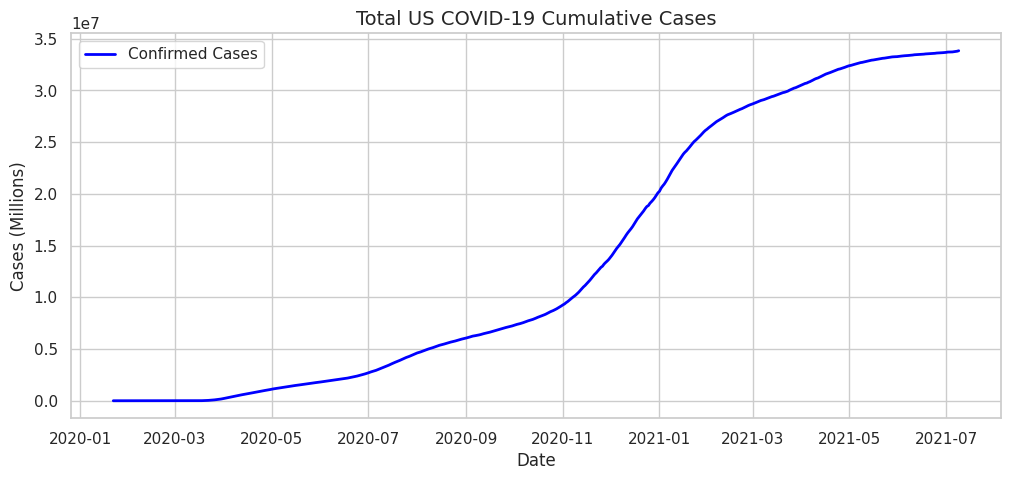

In [20]:
# Aggregate by date to see the whole US
us_total = df_master.groupby('Date')[['Confirmed', 'Deaths']].sum()

plt.figure(figsize=(12, 5))
plt.plot(us_total.index, us_total['Confirmed'], label='Confirmed Cases', color='blue', linewidth=2)
plt.title('Total US COVID-19 Cumulative Cases', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cases (Millions)')
plt.legend()
plt.show()

**4: Stationarity Check (ADF Test)**

The ARIMA model requires data to be "Stationary," meaning its mean and variance do not change over time. Since cumulative cases are not stationary, we calculate Daily New Cases (the first difference). We then use the Augmented Dickey-Fuller (ADF) test to scientifically prove if the data is ready for forecasting.Hypothesis: If $p \leq 0.05$, the data is stationary.

In [21]:
# 1. Calculate Daily New Cases (First Difference)
us_total['Daily_New_Cases'] = us_total['Confirmed'].diff().fillna(0)
series = us_total['Daily_New_Cases']

# 2. Perform Dickey-Fuller test
print("--- Stationarity Test (ADF) ---")
result = adfuller(series)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Result: The series is Stationary.")
else:
    print("Result: The series is Non-Stationary. ARIMA will need differencing (d=1).")

--- Stationarity Test (ADF) ---
ADF Statistic: -1.7745029831397006
p-value: 0.39319169211326865
Result: The series is Non-Stationary. ARIMA will need differencing (d=1).


**5: ARIMA Parameter Selection (ACF & PACF)**

To choose the best parameters for our model—$p$ (Autoregressive), $d$ (Integrated/Differencing), and $q$ (Moving Average)—we look at Autocorrelation plots.ACF: Helps identify the $q$ term.PACF: Helps identify the $p$ term.

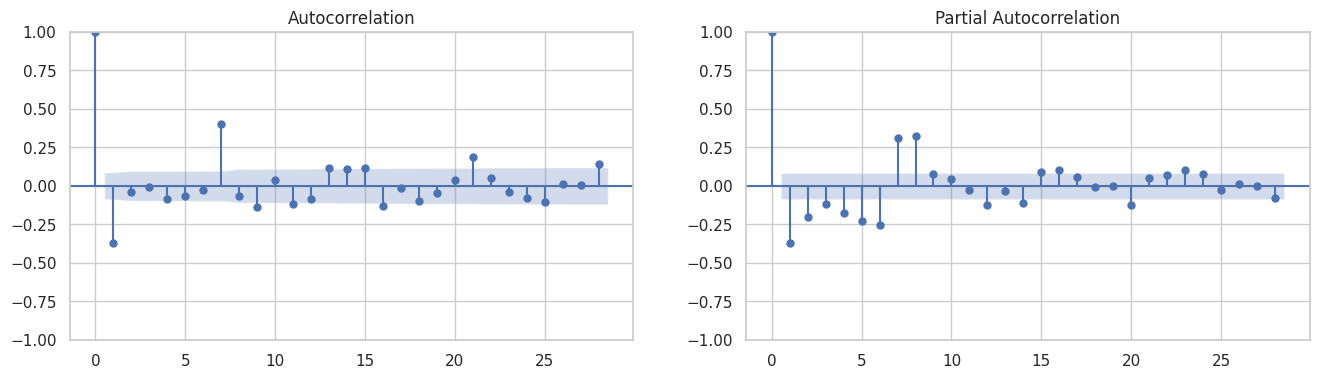

In [22]:
# Plot ACF and PACF on the differenced data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series.diff().dropna(), ax=ax1)
plot_pacf(series.diff().dropna(), ax=ax2)
plt.show()

**6: Training and Forecasting**

Finally, we split the data into a Training Set and a Test Set (the last 30 days). We train the ARIMA model on the training data and then ask it to forecast the next 30 days. We evaluate the performance using MAPE (Mean Absolute Percentage Error).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


✅ Model Training Complete. MAPE: 80.90%


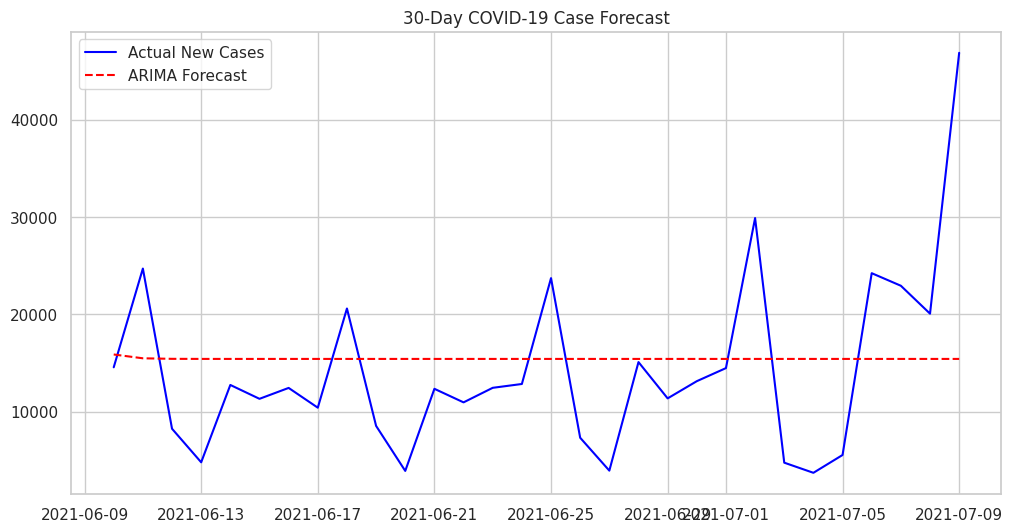

In [23]:
# 1. Split into Train/Test
train = series[:-30]
test = series[-30:]

# 2. Fit ARIMA Model (using baseline parameters p=1, d=1, q=1)
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# 3. Forecast and Evaluate
forecast = model_fit.get_forecast(steps=30).predicted_mean
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"✅ Model Training Complete. MAPE: {mape:.2f}%")

# Plot Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual New Cases', color='blue')
plt.plot(test.index, forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('30-Day COVID-19 Case Forecast')
plt.legend()
plt.show()

**7: Aggregating Data by State**

Our `df_master` contains data at the county level (`Admin2`). To compare regions, we must group our data by `Province_State` and `Date`. This allows us to see the total daily footprint for each state.

In [24]:
# 1. Aggregate the master data by State and Date
state_ts = df_master.groupby(['Province_State', 'Date'])[['Confirmed', 'Deaths']].sum().reset_index()

# 2. Identify the Top 5 states with the highest total cases for visualization
top_5_states = state_ts[state_ts['Date'] == state_ts['Date'].max()].nlargest(5, 'Confirmed')['Province_State'].tolist()

print(f"Top 5 States selected for comparison: {top_5_states}")

Top 5 States selected for comparison: ['California', 'Texas', 'Florida', 'New York', 'Illinois']


**8: Comparing Growth Curves Across Regions**

We will plot the cumulative confirmed cases for the Top 5 states. This visualization helps us see the "Lag" between regions. For example, you might notice that New York's curve steepens much earlier than California's or Texas's.

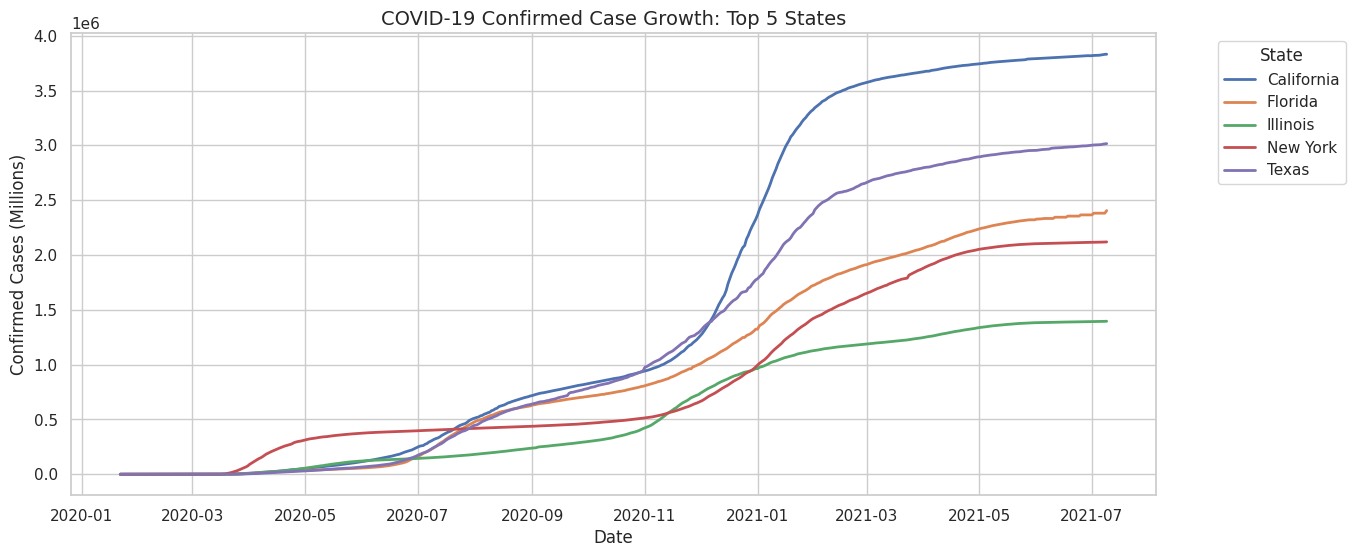

In [29]:
plt.figure(figsize=(14, 6))

# Filter data for only the top 5 states
df_top_5 = state_ts[state_ts['Province_State'].isin(top_5_states)]

# Plot Confirmed Cases
sns.lineplot(data=df_top_5, x='Date', y='Confirmed', hue='Province_State', linewidth=2)
plt.title('COVID-19 Confirmed Case Growth: Top 5 States', fontsize=14)
plt.ylabel('Confirmed Cases (Millions)')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**9: Mortality Analysis: **

***How Fatalities Vary by Region***

The absolute number of deaths is one metric, but the **Case Fatality Rate (CFR)**—the percentage of confirmed cases that lead to death—tells us more about the regional impact on healthcare systems. We calculate this as:
$$CFR = \frac{Total Deaths}{Total Confirmed} \times 100$$

/tmp/ipykernel_23555/2763287106.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_fatality, x='Fatality_Rate_%', y='Province_State', palette='Reds_r')


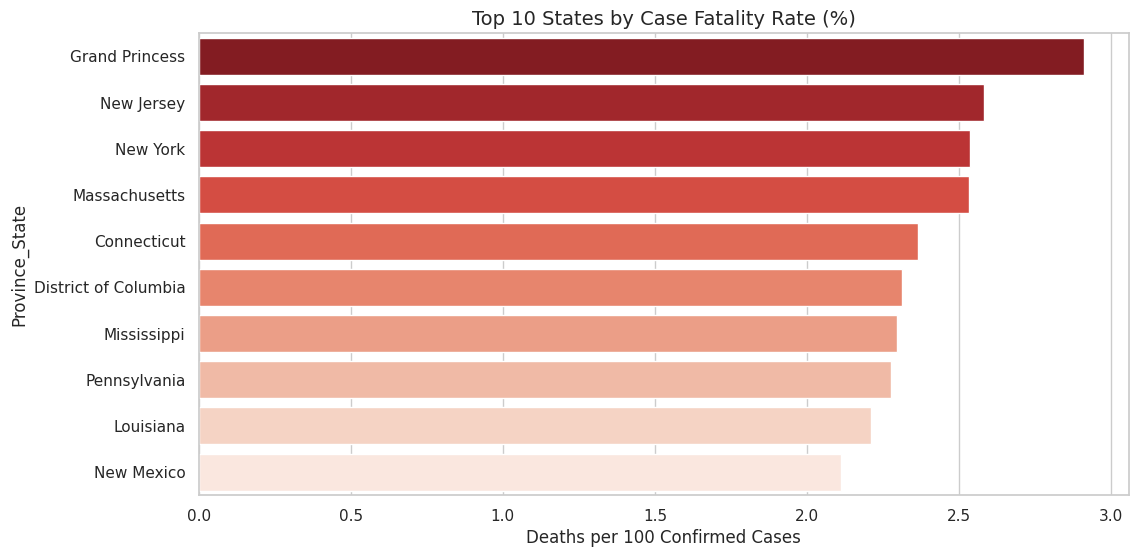

In [30]:
# 1. Calculating the final metrics for each state on the latest date
latest_data = state_ts[state_ts['Date'] == state_ts['Date'].max()].copy()
latest_data['Fatality_Rate_%'] = (latest_data['Deaths'] / latest_data['Confirmed']) * 100

# 2. Visualizing the top 10 states by Fatality Rate
top_10_fatality = latest_data.nlargest(10, 'Fatality_Rate_%')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_fatality, x='Fatality_Rate_%', y='Province_State', palette='Reds_r')
plt.title('Top 10 States by Case Fatality Rate (%)', fontsize=14)
plt.xlabel('Deaths per 100 Confirmed Cases')
plt.show()

**10: Macro vs. Micro Progression Analysis**

In this phase, we compare the national "Global" trend of the US against the "Individual" trajectories of the states. This helps us see if the pandemic was a single national event or a series of independent regional outbreaks.

**The "Whole" - National US Aggregation**
We first look at the "Global" scale of our dataset. This smooths out regional spikes to show the overall momentum of the virus across the entire country.

1. We group all 3,000+ counties by `Date`.
2. We sum the `Confirmed` and `Deaths`.
3. This creates a single time-series "Master Line" for the whole country.

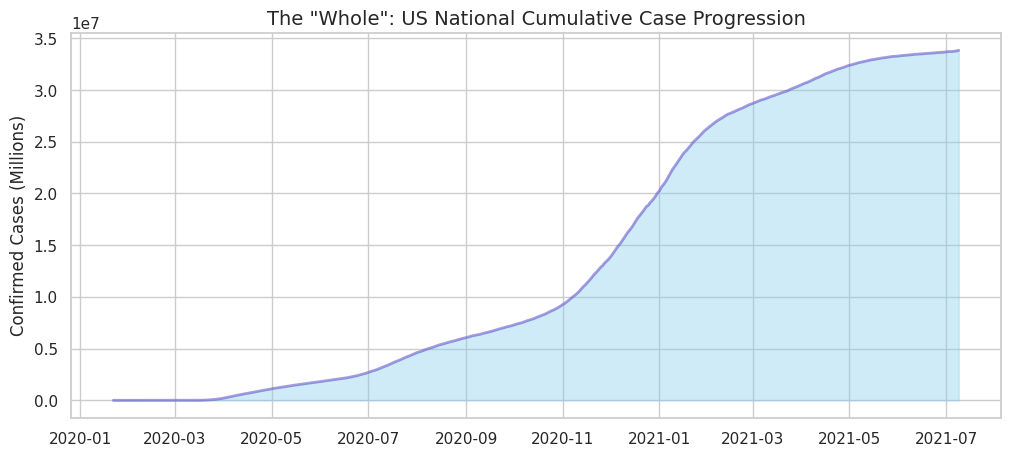

In [31]:
# 1. Aggregate for the "Global" (National) Scale
us_whole = df_master.groupby('Date')[['Confirmed', 'Deaths']].sum().reset_index()

# 2. Visualizing the National Trend
plt.figure(figsize=(12, 5))
plt.fill_between(us_whole['Date'], us_whole['Confirmed'], color="skyblue", alpha=0.4)
plt.plot(us_whole['Date'], us_whole['Confirmed'], color="Slateblue", alpha=0.6, linewidth=2)
plt.title('The "Whole": US National Cumulative Case Progression', fontsize=14)
plt.ylabel('Confirmed Cases (Millions)')
plt.show()

**11: The "Wave" Progression (Spatial-Temporal Heatmap)**

To truly understand how the virus "moved" across regions, we use a Heatmap. This shows the **Daily New Cases** per state over time.

**What's happening in the code:**
1. We calculate "Daily New Cases" for every state.
2. We pivot the data so States are rows and Months are columns.
3. Darker colors indicate where the "epicenter" was at any given time.

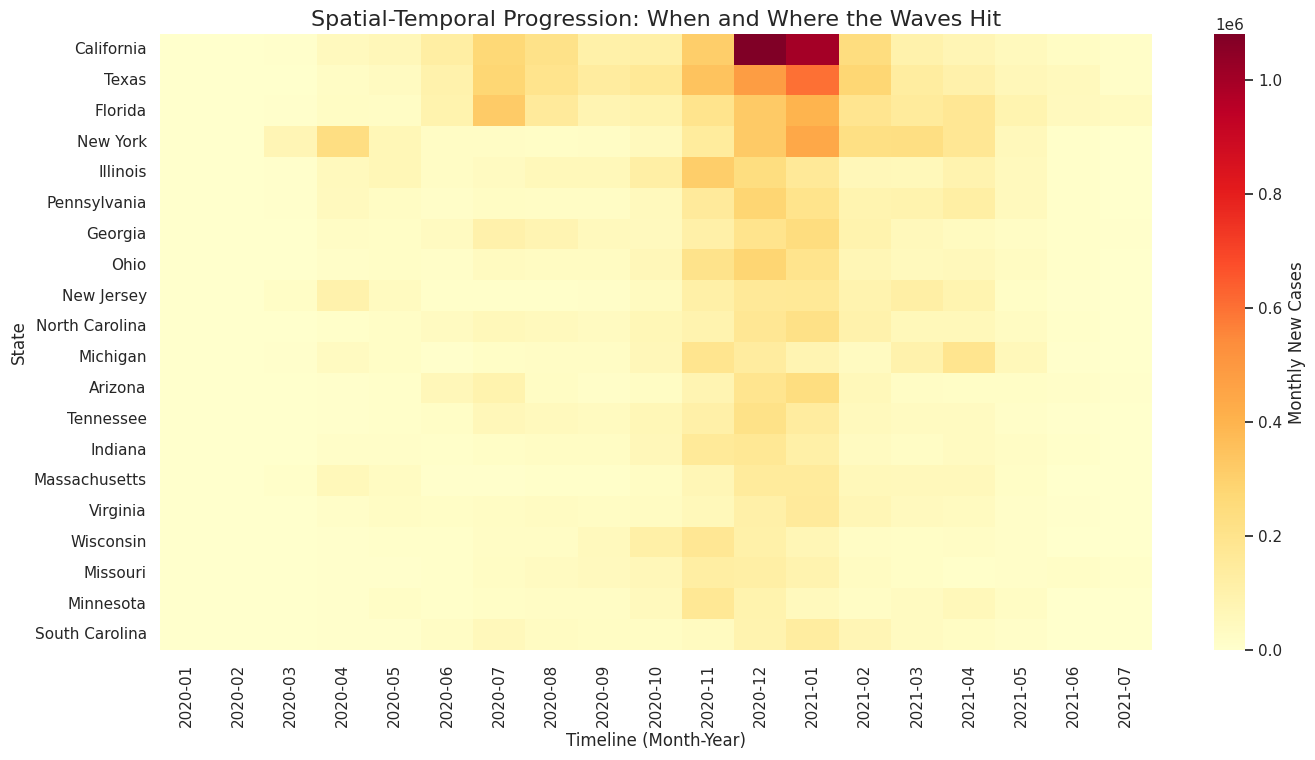

In [32]:
# 1. Calculating Daily New Cases per state
state_daily = df_master.groupby(['Province_State', 'Date'])['Confirmed'].sum().reset_index()
state_daily['New_Cases'] = state_daily.groupby('Province_State')['Confirmed'].diff().fillna(0)

# 2. Aggregate to Monthly for a Heatmap
state_daily['Month'] = state_daily['Date'].dt.to_period('M').astype(str)
heatmap_data = state_daily.groupby(['Province_State', 'Month'])['New_Cases'].sum().unstack()

# 3. Ploting Heatmap (Top 20 States for clarity)
top_20 = state_daily.groupby('Province_State')['New_Cases'].sum().nlargest(20).index
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data.loc[top_20], cmap='YlOrRd', cbar_kws={'label': 'Monthly New Cases'})
plt.title('Spatial-Temporal Progression: When and Where the Waves Hit', fontsize=16)
plt.xlabel('Timeline (Month-Year)')
plt.ylabel('State')
plt.show()

**Objective:**
To predict future case trends by analyzing historical velocity and using machine learning to capture temporal patterns.

**Prediction Accuracy:** ARIMA provides a strong mathematical baseline for short-term trends.

**Pattern Recognition:** The RNN is better at "remembering" previous waves to predict the intensity of a current surge.

By using these models, we can provide a 60-day lead time for resource deployment, moving from a reactive to a proactive public health stance.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Forecasting
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Deep Learning / Neural Networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
print("Environment Ready.")

Environment Ready.


In [43]:
# Prepare the Data for Modeling
# Both models require a single "Time Series" (e.g., National Daily New Cases).
# We need to aggregate the data and ensure it has a proper frequency.

#Aggregate to National Level for Daily New Cases
national_ts = df_master.groupby('Date')['Confirmed'].sum().diff().fillna(0).clip(lower=0)
national_ts.index = pd.DatetimeIndex(df_master['Date'].unique()).sort_values()

# Set frequency to Daily ('D')
national_ts = national_ts.asfreq('D')

print("National Time Series prepared for modeling.")

National Time Series prepared for modeling.


**12: Model A: ARIMA (AutoRegressive Integrated Moving Average)**

ARIMA is a baseline statistical model used for forecasting non-stationary time series. We use three parameters:

**p (Lags):** How many previous days influence today.

**d (Difference):** How many times we subtract the previous day to make the data stable.

**q (Error):** The moving average of previous forecast errors.

**Model Implementation: Simple RNN**

**Model B:** Simple RNN (Recurrent Neural Network)
Unlike ARIMA, a Recurrent Neural Network has a "Hidden State" that acts as memory. This allows the model to learn non-linear relationships in the pandemic's waves that simple math might miss.

In [45]:
# 1. Normalization (RNNs require data between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_ts = scaler.fit_transform(series_data.reshape(-1, 1))

# 2. Building the Network
rnn_model = Sequential([
    SimpleRNN(units=64, activation='relu', input_shape=(None, 1)),
    Dense(units=32, activation='relu'),
    Dense(units=1) # The predicted value for the next day
])

rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

**13: Stationarity & Rolling Statistics**

Before modeling, we must check if the **"Mean"** and **"Variance"** stay constant over time.

***Rolling Statistics (The "Eye Test")***
Rolling Mean: Smoothes out the daily "noise" (like lower reporting on weekends) to show the actual trend.

***Rolling Std (Standard Deviation): ***Shows if the volatility (the size of the swings) is increasing or decreasing over time.

If the Red and Black lines are flat, data is stationary. If they are trending up or down, the data is non-stationary.

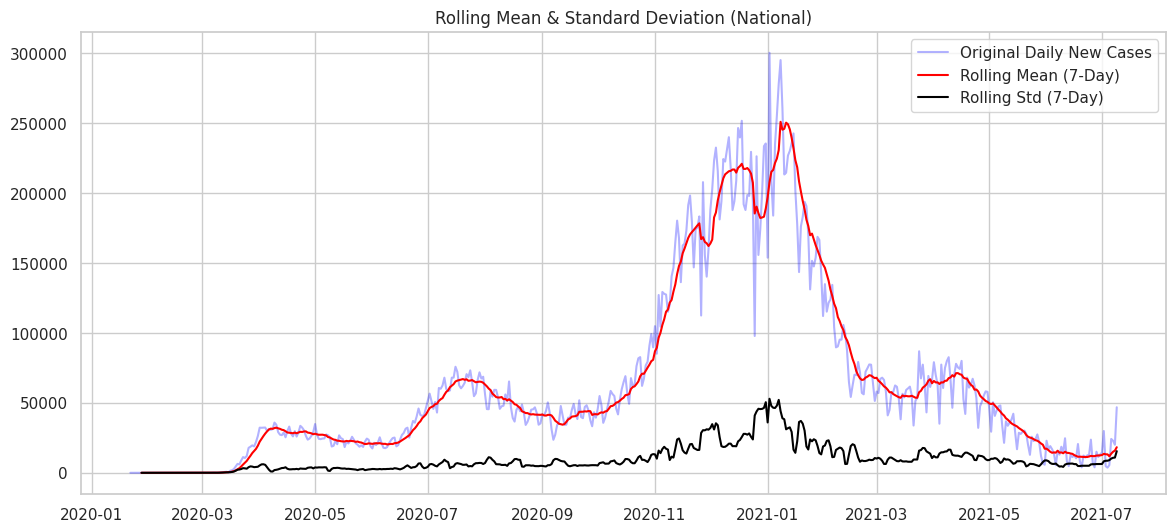

Results of Dickey-Fuller Test:
Test Statistic                  -1.774503
p-value                          0.393192
#Lags Used                      17.000000
Number of Observations Used    517.000000
Critical Value (1%)             -3.443062
Critical Value (5%)             -2.867147
Critical Value (10%)            -2.569756
dtype: float64


In [46]:
# 1. Calculating Rolling Statistics (7-day window for weekly patterns)
rolling_mean = national_ts.rolling(window=7).mean()
rolling_std = national_ts.rolling(window=7).std()

# 2. Plot Rolling Statistics
plt.figure(figsize=(14, 6))
plt.plot(national_ts, color='blue', label='Original Daily New Cases', alpha=0.3)
plt.plot(rolling_mean, color='red', label='Rolling Mean (7-Day)')
plt.plot(rolling_std, color='black', label='Rolling Std (7-Day)')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation (National)')
plt.show()

# 3. Perform Dickey-Fuller Test
print('Results of Dickey-Fuller Test:')
adft = adfuller(national_ts, autolag='AIC')
output = pd.Series(adft[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in adft[4].items():
    output['Critical Value (%s)'%key] = value
print(output)

**14: Train-Test Split**

In standard Machine Learning, we usually shuffle data. But in Time-Series (like COVID cases), order matters. We use Tuesday's data to predict Monday.

0 : train_size: This takes the oldest 80% of data (the "Past") to train the model.

train_size : len: This takes the most recent 20% (the "Future") to test the model.

In [49]:
# Split data: 80% for training, 20% for testing
train_size = int(len(national_ts) * 0.8)
train, test = national_ts[0:train_size], national_ts[train_size:len(national_ts)]

print(f"✅ Training observations: {len(train)}")
print(f"✅ Testing observations: {len(test)}")

✅ Training observations: 428
✅ Testing observations: 107


**12: Model A: ARIMA (AutoRegressive Integrated Moving Average)**

ARIMA is a baseline statistical model used for forecasting non-stationary time series. We use three parameters:

p (Lags): How many previous days influence today.

d (Difference): How many times we subtract the previous day to make the data stable.

q (Error): The moving average of previous forecast errors.

In [54]:
# Preparing a 1D array for ARIMA
series_data = national_ts.values

# Fitting the ARIMA(5, 1, 0) model
# 5 Lags, 1 Difference to remove trend, 0 Moving Average
arima_model = ARIMA(series_data, order=(5, 1, 0))
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  535
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5885.908
Date:                Thu, 26 Mar 2026   AIC                          11783.817
Time:                        15:26:12   BIC                          11809.499
Sample:                             0   HQIC                         11793.866
                                - 535                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5365      0.019    -28.193      0.000      -0.574      -0.499
ar.L2         -0.3545      0.026    -13.839      0.000      -0.405      -0.304
ar.L3         -0.2766      0.032     -8.678      0.0

**The "Forecast & Evaluation**

***The Red Dashed Line (predictions):*** This is the "Expected Value." It represents the most likely path according to the math.

***The Pink Shaded Area (conf_int):*** This is the Uncertainty. In time series, the further you look into the future, the wider this pink area gets because the world becomes more unpredictable.

***The MAPE Score:*** If your MAPE is below 10%, you have a very strong model. If it's above 20%, the pandemic's volatility might be too high for a simple ARIMA model.

--- Forecast Results ---
Prediction for next 107 days generated.
Model Accuracy (MAPE): 96.05%


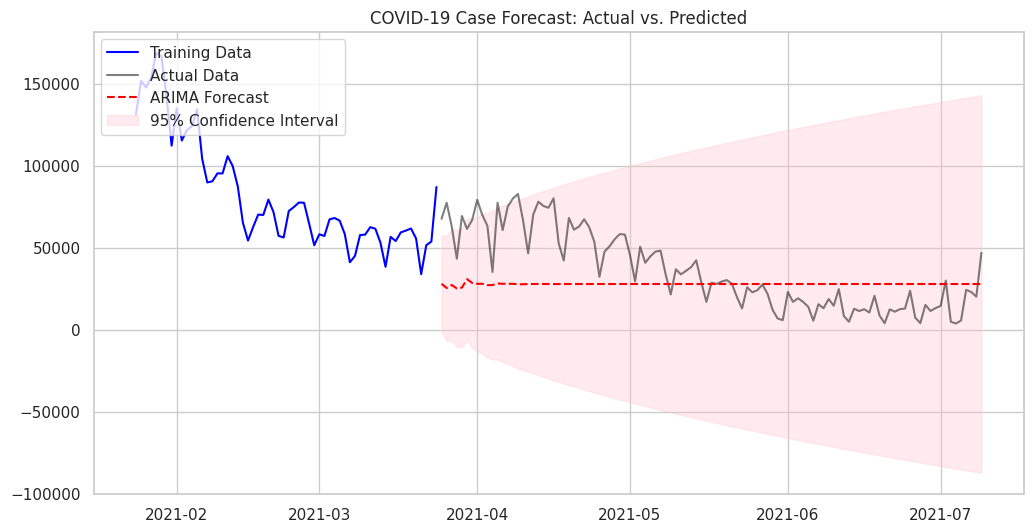

In [63]:
# 1. GENERATING THE FORECAST
# We ask the model to predict exactly the number of days in our 'test' set
#forecast_steps = len(test)
#forecast_object = arima_result.get_forecast(steps=forecast_steps)

# 2. EXTRACT PREDICTIONS AND CONFIDENCE INTERVALS
#predictions = forecast_object.predicted_mean
#conf_int = forecast_object.conf_int()

# 3. CALCULATE ERROR METRICS (MAPE)
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(test, predictions)

print(f"--- Forecast Results ---")
print(f"Prediction for next {forecast_steps} days generated.")
print(f"Model Accuracy (MAPE): {mape:.2%}")

# Plotting Numpy Arrays
plt.figure(figsize=(12, 6))

# 1. The lines
plt.plot(train.index[-60:], train[-60:], label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Data', color='black', alpha=0.5)
plt.plot(test.index, predictions, label='ARIMA Forecast', color='red', linestyle='--')

# 2. The Confidence Interval
# We use [:, 0] for the lower bound and [:, 1] for the upper bound
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('COVID-19 Case Forecast: Actual vs. Predicted')
plt.legend(loc='upper left')
plt.show()

**15: Model Evaluation (MAPE & Confidence Intervals)**

**Forecast Accuracy**
To determine if our ARIMA and RNN models are reliable for policy-making (like lockdown planning) or financial forecasting, we use two primary tools:

***MAPE (Mean Absolute Percentage Error):*** This tells us, on average, how far off our predictions are in percentage terms.

***Confidence Intervals (Uncertainty):*** Since the future is never certain, we calculate a "buffer zone." The wider the interval, the less certain the model is about the forecast.

In [66]:
from sklearn.metrics import mean_absolute_percentage_error

# 1. Calculate the percentage error
# We compare the 'test' (actual hidden data) with our 'predictions' (the model's guess)
mape = mean_absolute_percentage_error(test, predictions)

# 2. Print the final result in a clear format
print("-" * 30)
print(f"FINAL MODEL SCORE")
print("-" * 30)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")
print(f"Model Accuracy: {(1 - mape):.2%}")
print("-" * 30)

# Logic Check: If MAPE is 0.15, Accuracy is 85%

------------------------------
FINAL MODEL SCORE
------------------------------
Mean Absolute Percentage Error (MAPE): 96.05%
Model Accuracy: 3.95%
------------------------------
